[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase3_autoresearch/01_autoresearch_loop.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 3A - Autoresearch loop & group split

**Phase 3A - The autoresearch loop & why we split into groups.** Independent notebook - runs standalone in Colab or locally.

Loop: agent edits `train.py` -> 5-min train -> records `val_bpb` -> keep/revise/discard -> repeat. Memory-debug: remember which configs OOM/regressed so the agent avoids them. A single full sweep hits CUDA OOM at depth>=12, so we split into groups (deeper models use a smaller batch):

| Group | configs (depth, batch) |
|---|---|
| A | (4,32),(6,32) |
| B | (8,32),(10,32) |
| C | (12,16),(14,16) |
| D | (16,16),(18,16) |

## 0. Setup (self-contained)

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
SOURCE_DIR = <repo>/source


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

base_url = https://gateway.dahono.com/v1
model    = dahono/hy3
api_key  = set dahono…
llm      = (no llm client in this notebook — env vars set for CLI tools)


### 📊 Visualize — the autonomous-research loop

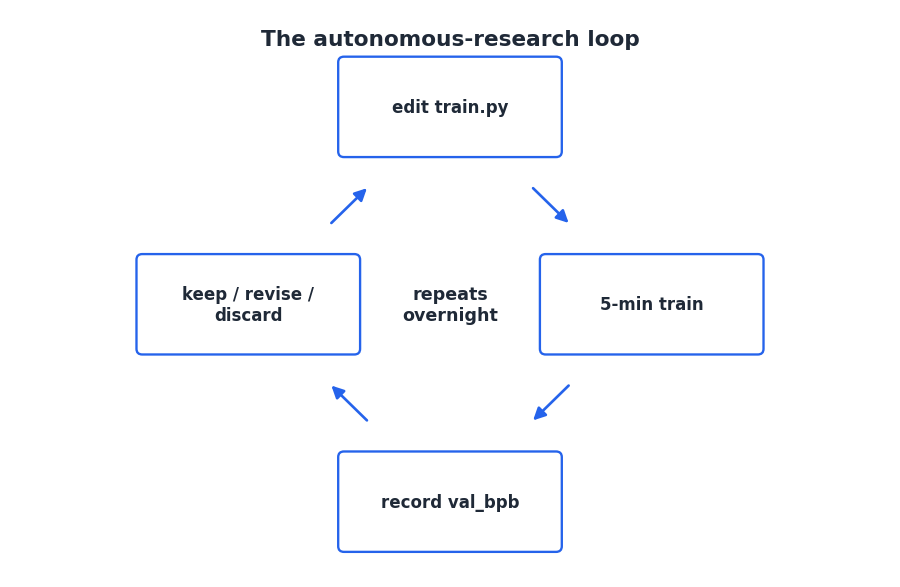

In [3]:
import matplotlib.pyplot as plt, math
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
PRIMARY="#1F2937"; ACCENT="#2563EB"
fig,ax=plt.subplots(figsize=(7.6,5.0),dpi=120); ax.set_axis_off(); ax.set_xlim(0,7.6); ax.set_ylim(0,5.0)
ax.text(3.8,4.7,"The autonomous-research loop",ha="center",fontsize=13,color=PRIMARY,weight="bold")
cx,cy,r=3.8,2.4,1.75
steps=["edit train.py","5-min train","record val_bpb","keep / revise /\ndiscard"]
pts=[(cx+r*math.cos(math.pi/2-i*math.pi/2), cy+r*math.sin(math.pi/2-i*math.pi/2)) for i in range(4)]
def _box(x,y,w,h,t):
    ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.02,rounding_size=0.05",fc="white",ec=ACCENT,lw=1.4))
    ax.text(x,y,t,ha="center",va="center",fontsize=10,color=PRIMARY,weight="bold")
for i in range(4):
    x,y=pts[i]; _box(x,y,1.9,0.85,steps[i]); nx,ny=pts[(i+1)%4]
    ax.add_patch(FancyArrowPatch((x+(nx-x)*0.4,y+(ny-y)*0.4),(nx-(nx-x)*0.4,ny-(ny-y)*0.4),arrowstyle="-|>",mutation_scale=15,color=ACCENT,lw=1.6))
ax.text(cx,cy,"repeats\novernight",ha="center",va="center",fontsize=10.5,color=PRIMARY,weight="bold")
fig.tight_layout(); plt.show()